In [1]:
import pandas as pd

df = pd.read_csv('/content/variability_dataset- Activity 2.csv')

print("First 5 rows of the dataset:")
display(df.head())

print("\nDataFrame Info:")
df.info()

First 5 rows of the dataset:


,date,measurement_id,value
0,2025-01-01,1,54.47
1,2025-01-01,2,51.30
2,2025-01-01,3,55.23
3,2025-01-02,1,61.51
4,2025-01-02,2,52.72



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     object 
 1   measurement_id  90 non-null     int64  
 2   value           90 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 2.2+ KB


In [4]:
df['date'] = pd.to_datetime(df['date'])

# Calculate daily mean and standard deviation of 'value'
daily_stats = df.groupby('date')['value'].agg(['mean', 'min', 'max']).reset_index()

print("Daily statistics:")
display(daily_stats.head())

Daily statistics:


,date,mean,min,max
0,2025-01-01,53.666667,51.30,55.23
1,2025-01-02,55.650000,52.72,61.51
2,2025-01-03,58.773333,53.30,63.54
3,2025-01-04,56.530000,54.84,59.89
4,2025-01-05,52.753333,48.85,59.62


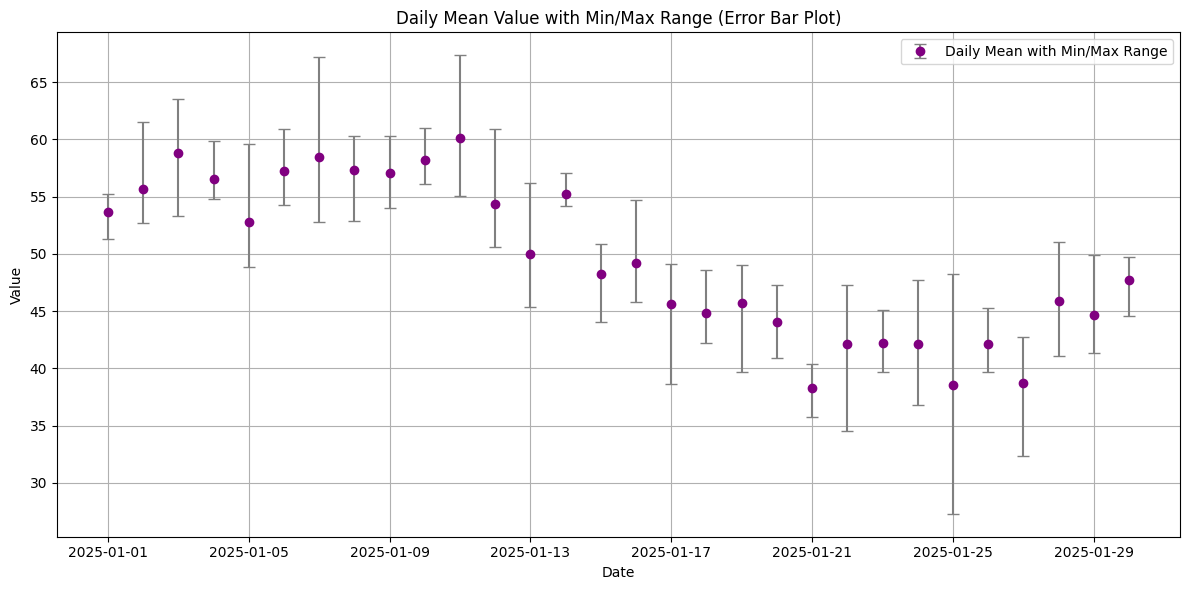

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Calculate yerr for error bars: difference between mean and min, and max and mean
yerr_lower = daily_stats['mean'] - daily_stats['min']
yerr_upper = daily_stats['max'] - daily_stats['mean']

plt.errorbar(
    x=daily_stats['date'],
    y=daily_stats['mean'],
    yerr=[yerr_lower, yerr_upper],
    fmt='o', # Format as circles for scatter points
    color='purple',
    ecolor='gray',
    capsize=4,
    label='Daily Mean with Min/Max Range'
)

plt.title('Daily Mean Value with Min/Max Range (Error Bar Plot)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()